# Forest Sketch scaling benchmarks

This notebook measures how Forest Sketch scales with the number of samples and input features. It records wall-clock time, process CPU time, and peak memory. The benchmark intentionally uses a small, single-threaded forest so the curves are reproducible on a laptop. The scaling figures use log-log axes.

The experiment measures `fit_transform`, which includes the initial projection, every forest/path extraction stage, and the final projection. Dataset generation is excluded from the timed region.

In [1]:
import warnings
from sklearn.random_projection import DataDimensionalityWarning
warnings.filterwarnings(
    "ignore",
    category=DataDimensionalityWarning,
    message="The number of components is higher than the number of features.*",
)

import gc
import importlib.util
import os
import threading
import time
import tracemalloc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

from forestsketch import ForestSketchEstimator

RANDOM_STATE = 42
RULE_MULTIPLIER = 20
N_ITERATIONS = 2
N_ESTIMATORS = 100

HAS_PSUTIL = importlib.util.find_spec("psutil") is not None
if HAS_PSUTIL:
    import psutil

def current_rss_mb():
    if not HAS_PSUTIL:
        return np.nan
    return psutil.Process(os.getpid()).memory_info().rss / 2**20

def benchmark_case(n_samples, n_features, sweep, seed):
    n_informative = max(2, min(n_features - 1, n_features // 2))
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        random_state=seed,
    )
    sketch = ForestSketchEstimator(
        estimator=RandomForestClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=8,
            n_jobs=-1,
            random_state=seed,
        ),
        n_components=RULE_MULTIPLIER * n_features,
        n_iterations=N_ITERATIONS,
        random_state=seed,
    )

    gc.collect()
    rss_before = current_rss_mb()
    peak_rss = [rss_before]
    stop_sampling = threading.Event()

    def sample_rss():
        while not stop_sampling.wait(0.01):
            rss = current_rss_mb()
            if not np.isnan(rss):
                peak_rss[0] = max(peak_rss[0], rss)

    sampler = threading.Thread(target=sample_rss, daemon=True)
    tracemalloc.start()
    sampler.start()
    wall_start = time.perf_counter()
    cpu_start = time.process_time()
    X_sketch = sketch.fit_transform(X, y)
    cpu_seconds = time.process_time() - cpu_start
    wall_seconds = time.perf_counter() - wall_start
    stop_sampling.set()
    sampler.join()
    _, peak_python_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "sweep": sweep,
        "n_samples": n_samples,
        "n_features": n_features,
        "target_dimension": RULE_MULTIPLIER * n_features,
        "wall_clock_seconds": wall_seconds,
        "cpu_seconds": cpu_seconds,
        "peak_python_mb": peak_python_bytes / 2**20,
        "peak_rss_mb": peak_rss[0],
        "rss_delta_mb": peak_rss[0] - rss_before if not np.isnan(peak_rss[0]) else np.nan,
        "output_nbytes": X_sketch.nbytes,
        "output_nonzeros": int(np.count_nonzero(X_sketch)),
    }

## Run the scaling grid

The sample sweep holds the feature count at 32. The feature sweep holds the sample count at 512. Increase these ranges for a larger study, but expect runtime and memory use to grow accordingly.

In [2]:
print("Rule of thumb: target_dimension = 20 * n_features for every benchmark case")
sample_sizes = [256, 512, 1024, 2048]
feature_sizes = [16, 32, 64, 128]

records = []
for index, n_samples in enumerate(sample_sizes):
    records.append(benchmark_case(n_samples, 32, "samples", RANDOM_STATE + index))
for index, n_features in enumerate(feature_sizes):
    records.append(benchmark_case(512, n_features, "features", RANDOM_STATE + 100 + index))

results = pd.DataFrame(records)
results["output_mb"] = results["output_nbytes"] / 2**20
results

Rule of thumb: target_dimension = 20 * n_features for every benchmark case


,sweep,n_samples,n_features,target_dimension,wall_clock_seconds,cpu_seconds,peak_python_mb,peak_rss_mb,rss_delta_mb,output_nbytes,output_nonzeros,output_mb
0,samples,256,32,640,0.707695,0.881578,59.152903,313.750000,84.968750,1310720,163840,1.25
1,samples,512,32,640,0.823841,1.341002,114.437220,443.468750,129.359375,2621440,327680,2.50
2,samples,1024,32,640,1.027882,2.300256,181.551749,638.640625,195.171875,5242880,655360,5.00
3,samples,2048,32,640,1.391884,4.992307,290.063477,931.406250,292.796875,10485760,1310720,10.00
4,features,512,16,320,0.711251,1.032039,57.427824,947.671875,16.296875,1310720,163840,1.25
5,features,512,32,640,0.816795,1.308651,107.858802,948.718750,1.078125,2621440,327680,2.50
6,features,512,64,1280,1.055843,1.789407,221.864460,976.265625,28.515625,5242880,655360,5.00
7,features,512,128,2560,1.726908,6.416856,468.093435,1503.062500,526.875000,10485760,1310720,10.00


In [3]:
display(
    results[
        [
            "sweep",
            "n_samples",
            "n_features",
            "wall_clock_seconds",
            "cpu_seconds",
            "peak_python_mb",
            "peak_rss_mb",
            "output_mb",
        ]
    ].round(3)
)

,sweep,n_samples,n_features,wall_clock_seconds,cpu_seconds,peak_python_mb,peak_rss_mb,output_mb
0,samples,256,32,0.708,0.882,59.153,313.750,1.25
1,samples,512,32,0.824,1.341,114.437,443.469,2.50
2,samples,1024,32,1.028,2.300,181.552,638.641,5.00
3,samples,2048,32,1.392,4.992,290.063,931.406,10.00
4,features,512,16,0.711,1.032,57.428,947.672,1.25
5,features,512,32,0.817,1.309,107.859,948.719,2.50
6,features,512,64,1.056,1.789,221.864,976.266,5.00
7,features,512,128,1.727,6.417,468.093,1503.062,10.00


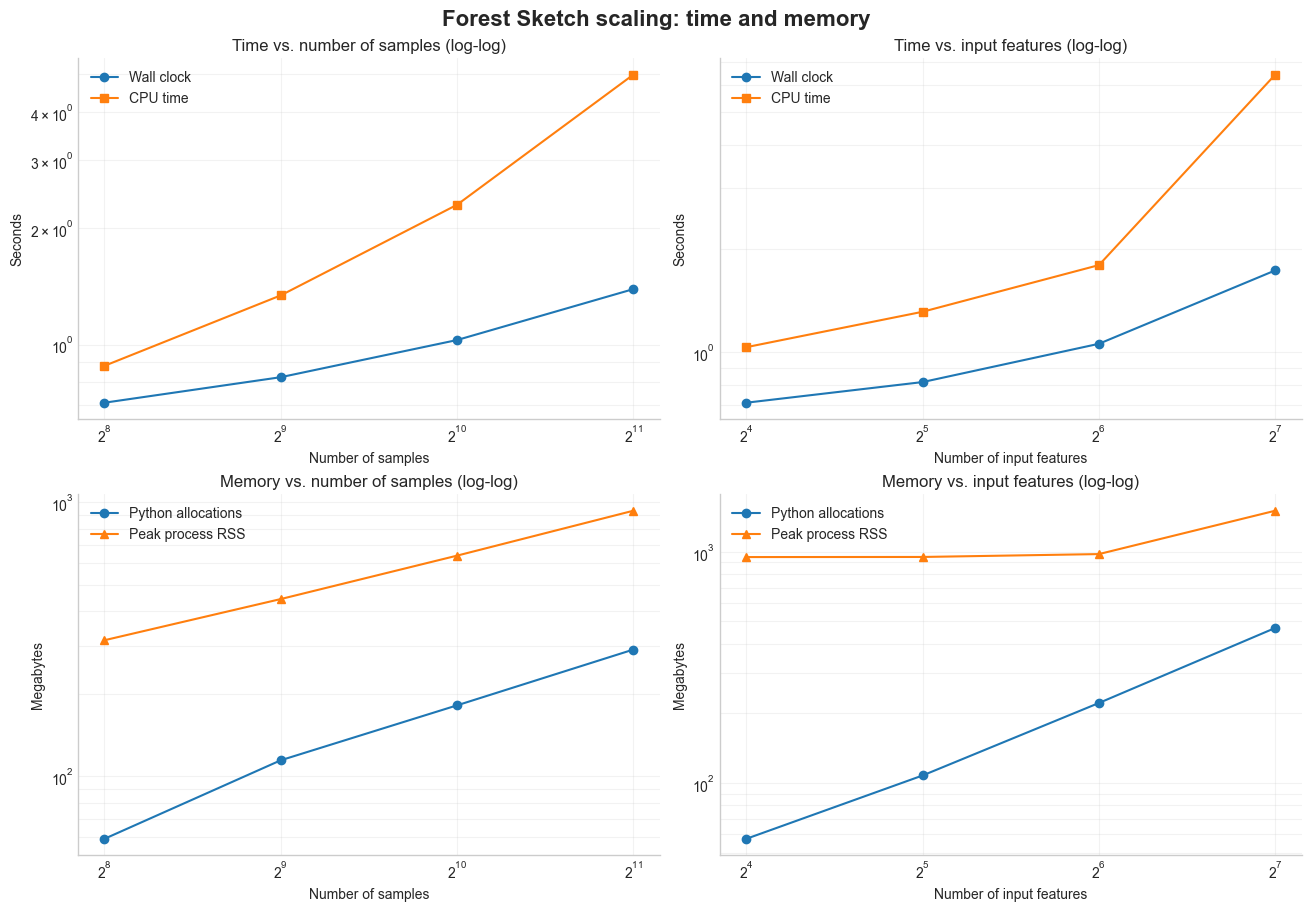

In [4]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
fig.suptitle("Forest Sketch scaling: time and memory", fontsize=16, fontweight="bold")

sample_results = results[results["sweep"] == "samples"].sort_values("n_samples")
feature_results = results[results["sweep"] == "features"].sort_values("n_features")

axes[0, 0].plot(sample_results["n_samples"], sample_results["wall_clock_seconds"], marker="o", label="Wall clock")
axes[0, 0].plot(sample_results["n_samples"], sample_results["cpu_seconds"], marker="s", label="CPU time")
axes[0, 0].set_title("Time vs. number of samples (log-log)")
axes[0, 0].set_xlabel("Number of samples")
axes[0, 0].set_ylabel("Seconds")
axes[0, 0].set_xscale("log", base=2)
axes[0, 0].legend()

axes[0, 1].plot(feature_results["n_features"], feature_results["wall_clock_seconds"], marker="o", label="Wall clock")
axes[0, 1].plot(feature_results["n_features"], feature_results["cpu_seconds"], marker="s", label="CPU time")
axes[0, 1].set_title("Time vs. input features (log-log)")
axes[0, 1].set_xlabel("Number of input features")
axes[0, 1].set_ylabel("Seconds")
axes[0, 1].set_xscale("log", base=2)
axes[0, 1].legend()

axes[1, 0].plot(sample_results["n_samples"], sample_results["peak_python_mb"], marker="o", label="Python allocations")
if sample_results["peak_rss_mb"].notna().any():
    axes[1, 0].plot(sample_results["n_samples"], sample_results["peak_rss_mb"], marker="^", label="Peak process RSS")
axes[1, 0].set_title("Memory vs. number of samples (log-log)")
axes[1, 0].set_xlabel("Number of samples")
axes[1, 0].set_ylabel("Megabytes")
axes[1, 0].set_xscale("log", base=2)
axes[1, 0].legend()

axes[1, 1].plot(feature_results["n_features"], feature_results["peak_python_mb"], marker="o", label="Python allocations")
if feature_results["peak_rss_mb"].notna().any():
    axes[1, 1].plot(feature_results["n_features"], feature_results["peak_rss_mb"], marker="^", label="Peak process RSS")
axes[1, 1].set_title("Memory vs. input features (log-log)")
axes[1, 1].set_xlabel("Number of input features")
axes[1, 1].set_ylabel("Megabytes")
axes[1, 1].set_xscale("log", base=2)
axes[1, 1].legend()

for axis in axes.flat:
    axis.set_yscale("log")
    axis.grid(True, which="both", alpha=0.25)
    axis.spines[["top", "right"]].set_visible(False)

plt.show()

## Reading the curves

Use wall-clock time for user-facing latency and CPU time for compute cost. On these log-log axes, a straight trend is consistent with power-law scaling; exponential growth would appear straight on a semi-log plot. `peak_python_mb` comes from `tracemalloc`; when `psutil` is available, `peak_rss_mb` captures the process-level resident-memory high-water mark during each case. These measurements are for relative scaling comparisons, not a substitute for a production workload profile.